# imports

In [1]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import __version__ as matplotlibV
import spkit as sp

print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlibV}")
print(f"spkit {sp.__version__}")


numpy: 2.4.6
matplotlib: 3.10.9
spkit 0.0.9.7


# Load the data

In [2]:
data = np.array(np.load('EEG_all_epochs.npy'))
print(len(data))
print(len(data[0]))
fs=512


4514
512


In [3]:
#print(pywt.families())
print(pywt.wavelist(kind='discrete'))
print(pywt.ContinuousWavelet('cgau1'))

['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'haar', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5', 'rbio6.8', 'sym2', 'sym3', 'sym4', 'sym5', 'sym6', 'sym7', 'sym8', 'sym9', 'sym10', 'sym11', 'sym12', 'sym13', 'sym14', 'sym15', 'sym16', 'sym17', 'sym18', 'sym19', 'sym20']
ContinuousWavelet cgau1
  Family n

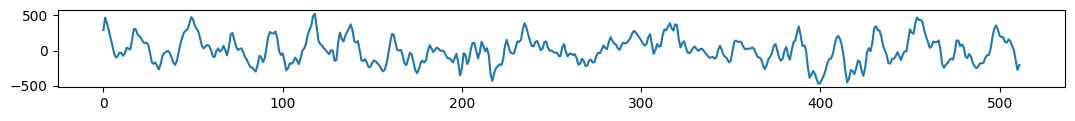

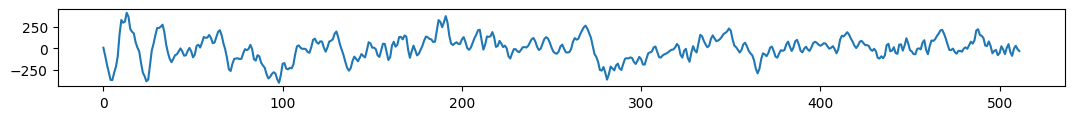

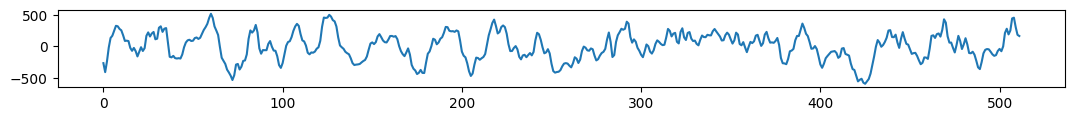

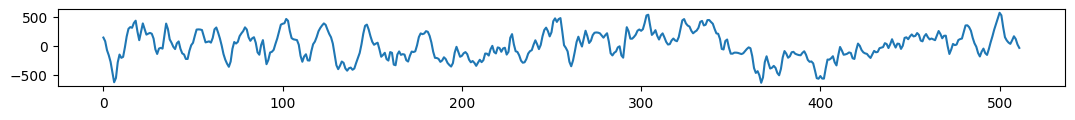

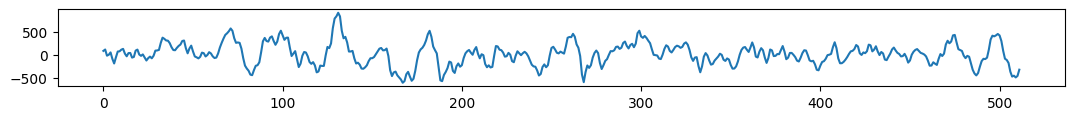

In [4]:
for i in range(600, 650, 10):
    plt.figure(figsize=(13, 1), dpi=100)
    plt.plot(range(len(data[i])), data[i])
    plt.show()

# Denoising and artifact removal

/Users/maximiliennotz/Desktop/Coding/GitHub/seizureDetection/.venv/lib/python3.14/site-packages/pywt/_functions.py:141: FutureWarning: Wavelets from the family shan, without parameters specified in the name are deprecated. The name should follow the format shanB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: shan = shan0.5-1.0).
/Users/maximiliennotz/Desktop/Coding/GitHub/seizureDetection/.venv/lib/python3.14/site-packages/pywt/_cwt.py:113: FutureWarning: Wavelets from the family shan, without parameters specified in the name are deprecated. The name should follow the format shanB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: shan = shan0.5-1.0).


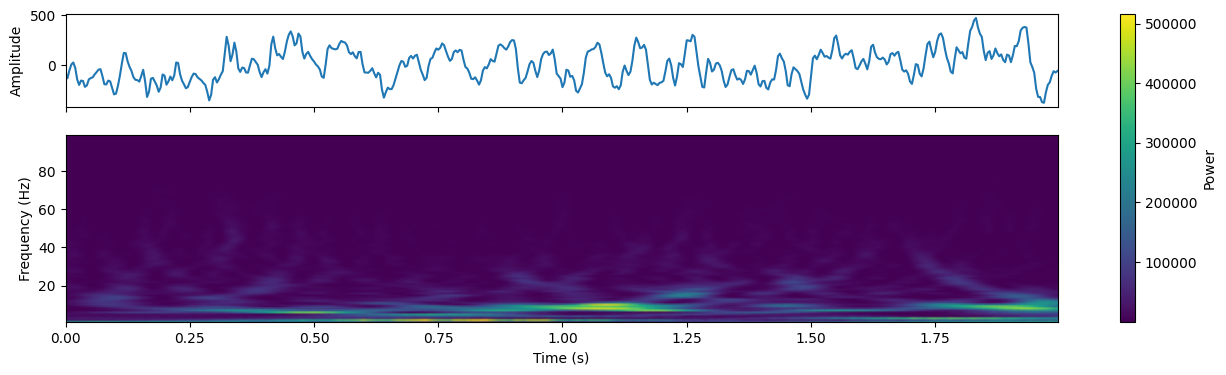

In [9]:
from util import plot

signal = data[1000]

plot(signal)

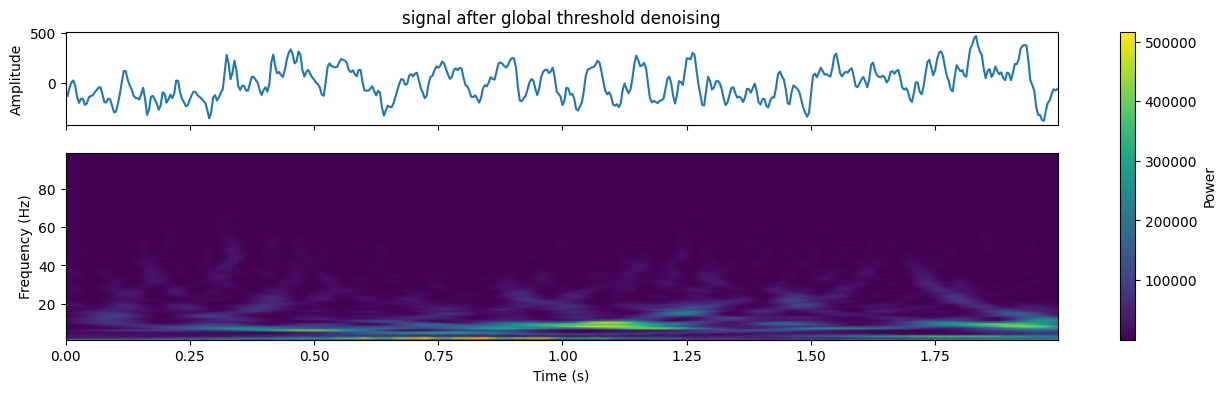

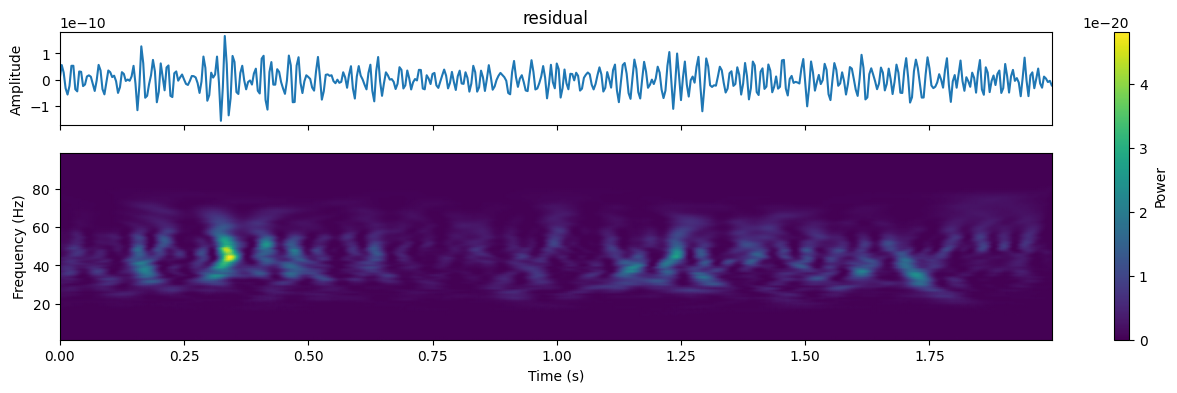

In [6]:
from util import global_threshold_denoising

newSignal = global_threshold_denoising(signal)
plot(newSignal, title = "signal after global threshold denoising")

residual = signal - newSignal
plot(residual, title = "residual")

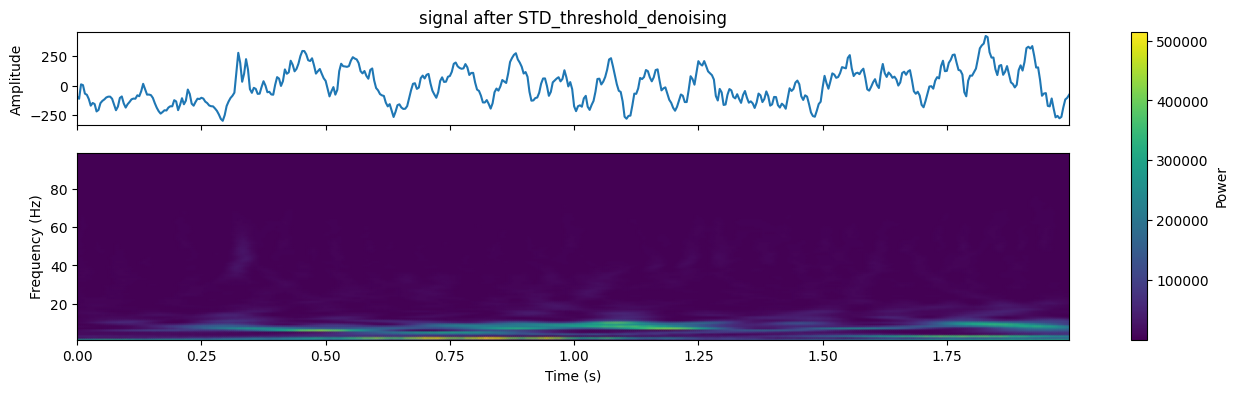

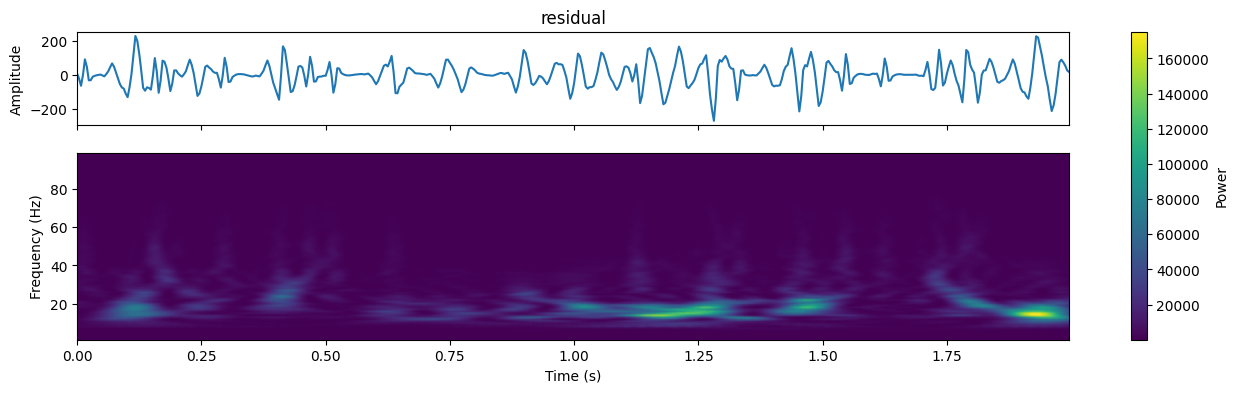

In [7]:
from util import STD_threshold_denoising

newSignal = STD_threshold_denoising(signal, level = 3)

plot(newSignal, title = "signal after STD_threshold_denoising")

residual = signal - newSignal
plot(residual, title = "residual")

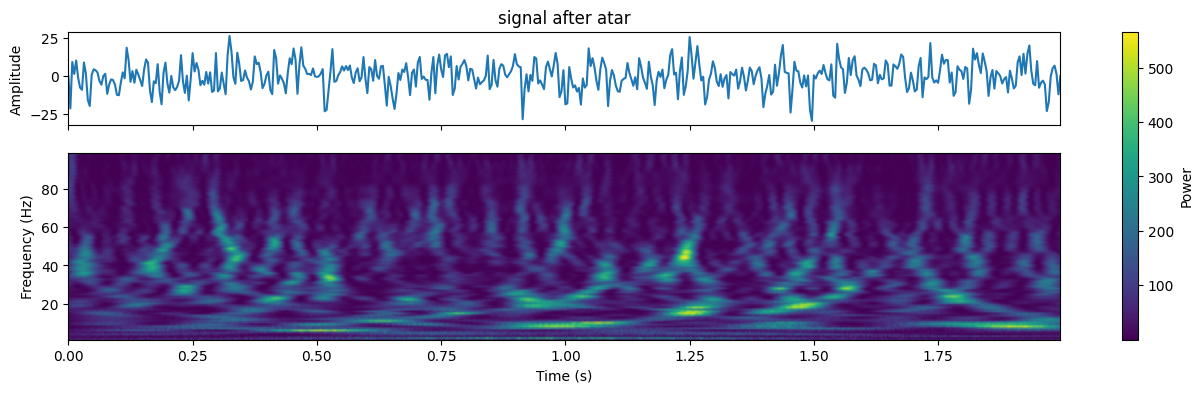

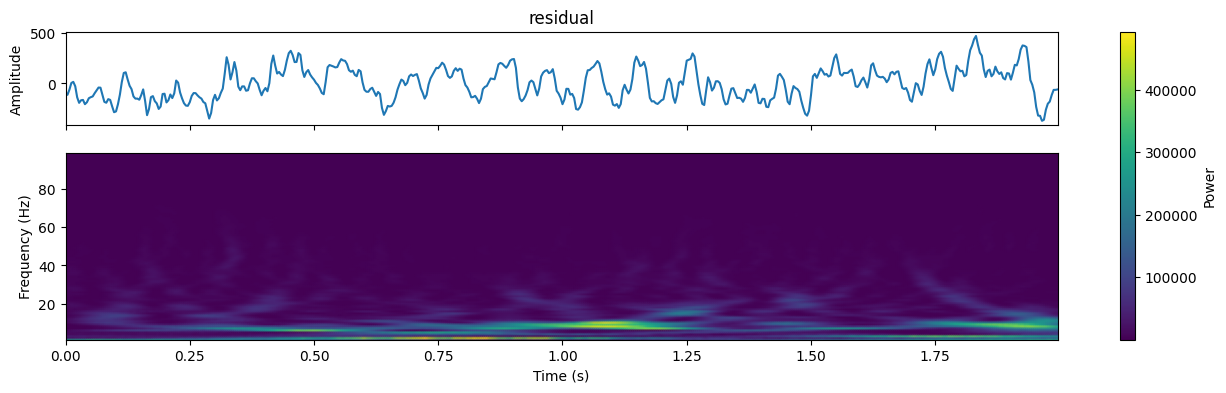

In [8]:
from util import atar

newSignal = atar(signal)

plot(newSignal, title = "signal after atar")

residual = signal - newSignal
plot(residual, title = "residual")